In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import os
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

#### 1. SETUP AND PATH CONFIGURATION

In [11]:
BASE_PATH = r"New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)"
TRAIN_DIR = os.path.join(BASE_PATH, "train")

In [12]:
# Define image and training parameters
IMAGE_SIZE = (150, 150) # Standard size for initial training
BATCH_SIZE = 32
RANDOM_SEED = 42

In [14]:
# Check if the path exists before proceeding
if not os.path.isdir(TRAIN_DIR):
    print(f"ERROR: The training directory was not found at '{TRAIN_DIR}'")
    print("Please verify the path and update the BASE_PATH variable.")
else :
    print("Training directory found. Proceeding with data loading and model training.")


Training directory found. Proceeding with data loading and model training.


#### 2. EXPLORATORY DATA ANALYSIS (EDA)

In [15]:
class_names = os.listdir(TRAIN_DIR)

In [18]:
class_names= [d for d in class_names if not d.startswith(".")]

In [19]:
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

Number of classes: 38


In [26]:
print([class_names[i] for i in range(5)])

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [28]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        # Count only image files
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = count

In [30]:
# Plot Class Distribution (Horizontal Bar Chart for readability)
sorted_counts = dict(sorted(class_counts.items(), key=lambda item: item[1]))
labels = list(sorted_counts.keys())
counts = list(sorted_counts.values())

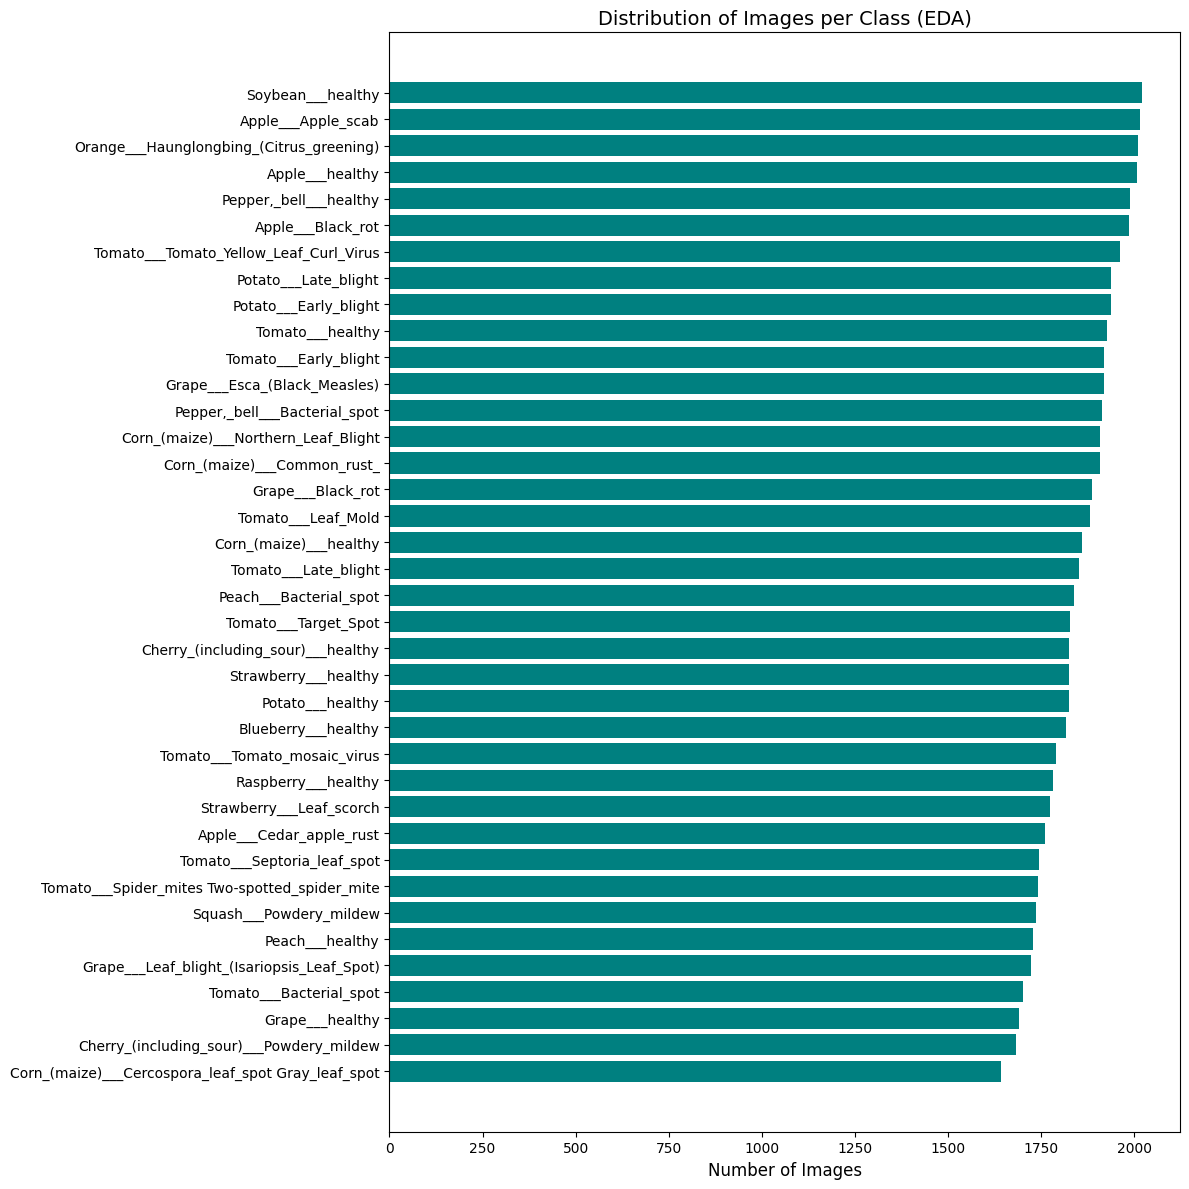


Total images found in training set: 70295
Class size range: Min=1642, Max=2022


In [31]:
plt.figure(figsize=(12, 12))
plt.barh(labels, counts, color='teal')
plt.xlabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Class (EDA)', fontsize=14)
plt.tight_layout()
plt.show()
print(f"\nTotal images found in training set: {sum(counts)}")
print(f"Class size range: Min={min(counts)}, Max={max(counts)}")

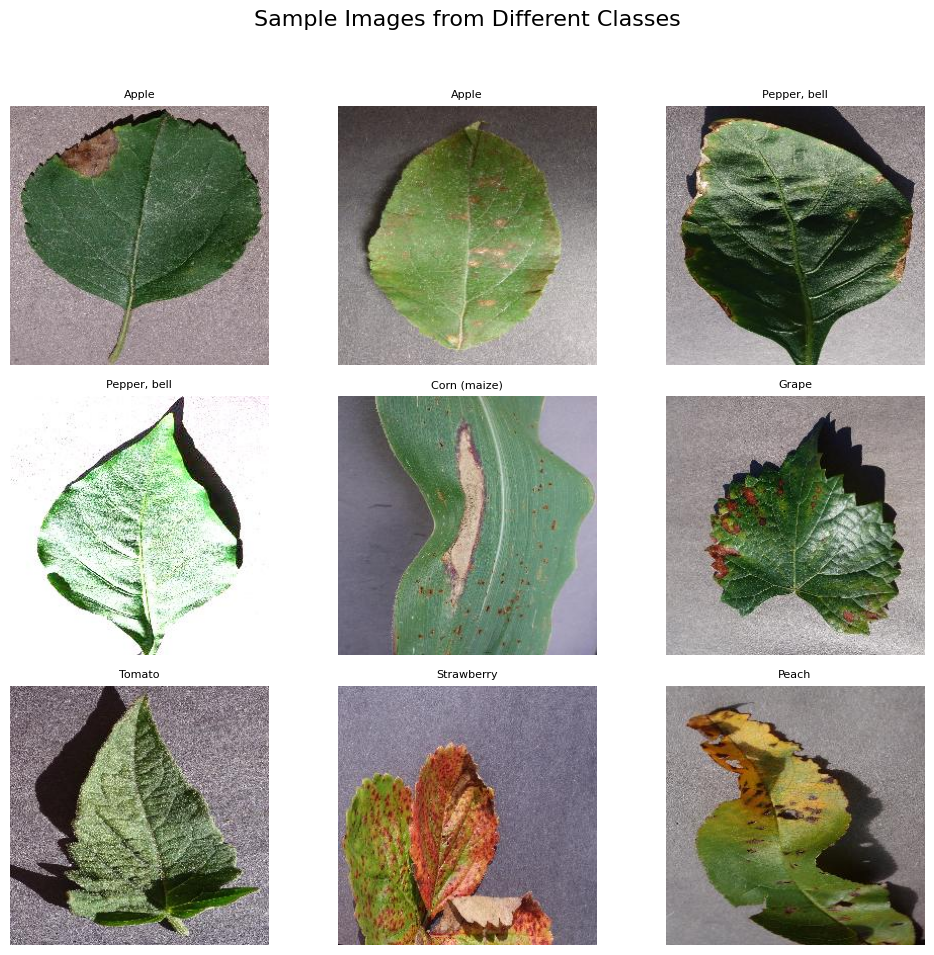

In [33]:
# Display a few sample images (UPDATED SECTION FOR ROBUSTNESS)
plt.figure(figsize=(10, 10))
plt.suptitle("Sample Images from Different Classes", fontsize=16)

# Select up to 9 random classes
sample_classes = random.sample(class_names, min(9, num_classes))
plotted_count = 0 # Track how many images were successfully plotted
for class_name in sample_classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    # Robustly list files and filter for common image extensions
    all_files = os.listdir(class_path)
    # Expanded list of common image extensions
    all_images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))] 
    if all_images and plotted_count < 9: # Check if images exist and we haven't plotted 9 yet
        try:
            img_name = random.choice(all_images)
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            plotted_count += 1
            plt.subplot(3, 3, plotted_count) # Use plotted_count to ensure sequential subplot filling
            plt.imshow(img)
            
            # Use only the disease/plant name for a cleaner title
            short_title = class_name.split('___')[0].replace('_', ' ')
            plt.title(f"{short_title}", fontsize=8)
            plt.axis('off')
        except Exception as plot_e:
            print(f"Warning: Could not open or plot image {img_path} (Class: {class_name}). Error: {plot_e}")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### 3. DATA PREPROCESSING AND AUGMENTATION

In [34]:
#  using one generator instance for both training and validation by specifying validation_split.
# This ensures that both sets are created from the TRAIN_DIR with a proper 80/20 split.
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Rescale pixel values (Normalization)
    rotation_range=20,              # Augmentation: Randomly rotate images
    width_shift_range=0.2,          # Augmentation: Randomly shift images horizontally
    height_shift_range=0.2,         # Augmentation: Randomly shift images vertically
    shear_range=0.2,
    zoom_range=0.2,                 # Augmentation: Randomly zoom in
    horizontal_flip=True,           # Augmentation: Randomly flip images
    fill_mode='nearest',
    validation_split=0.2            # Reserve 20% of images for validation
)

In [35]:
# Training Data Generator (80% of data for model training)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',       # Required for multi-class classification
    subset='training',              # Specify training data
    seed=RANDOM_SEED
)

Found 56251 images belonging to 38 classes.


In [36]:
# Validation Data Generator (20% of data for evaluating performance after each epoch)
validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',            # Specify validation data
    seed=RANDOM_SEED
)

Found 14044 images belonging to 38 classes.


#### 4. MODEL BUILDING (DEEPER CNN FOR BETTER ACCURACY)

In [37]:
model = Sequential([
    # Input Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    MaxPooling2D(2, 2),

    # Middle Block 1
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25), # Regularization

    # Middle Block 2
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Final Convolutional Block
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Classification Head
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Heavier dropout for the dense layer to prevent overfitting
    Dense(num_classes, activation='softmax') # Output layer, 'softmax' for probabilities
])

model.summary()

d:\My_Personal_Project\Plant_Disease\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,830,950 (26.06 MB)

 Trainable params: 6,830,950 (26.06 MB)

 Non-trainable params: 0 (0.00 B)

#### 5. MODEL COMPILATION

In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Standard loss for multi-class classification
    metrics=['accuracy']
)

#### 6. MODEL TRAINING WITH EARLY STOPPING

In [39]:
# Early Stopping Callback (Crucial for preventing overfitting and saving time)
early_stopping = EarlyStopping(
    monitor='val_loss',             # Quantity to be monitored (Validation Loss)
    patience=10,                    # Number of epochs with no improvement to wait
    restore_best_weights=True,      # Keep the weights that yielded the best performance
    verbose=1
)

In [41]:
# Training the model
MAX_EPOCHS = 50 # higher limit, Early Stopping will halt it sooner if needed

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # Calculate steps for one epoch
    epochs=MAX_EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping] # Apply the early stopping callback
)

Epoch 1/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.1658 - loss: 3.0259

d:\My_Personal_Project\Plant_Disease\myenv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1757/1757 ━━━━━━━━━━━━━━━━━━━━ 1166s 663ms/step - accuracy: 0.2998 - loss: 2.4527 - val_accuracy: 0.5425 - val_loss: 1.5047
Epoch 2/50
   1/1757 ━━━━━━━━━━━━━━━━━━━━ 4:52 167ms/step - accuracy: 0.5000 - loss: 1.6734

d:\My_Personal_Project\Plant_Disease\myenv\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1757/1757 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.5000 - loss: 1.6734 - val_accuracy: 0.5664 - val_loss: 1.4514
Epoch 3/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 412s 234ms/step - accuracy: 0.6087 - loss: 1.2687 - val_accuracy: 0.7385 - val_loss: 0.8419
Epoch 4/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.7812 - loss: 0.7122 - val_accuracy: 0.7366 - val_loss: 0.8348
Epoch 5/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 414s 236ms/step - accuracy: 0.7111 - loss: 0.9141 - val_accuracy: 0.8024 - val_loss: 0.6240
Epoch 6/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.7812 - loss: 0.6358 - val_accuracy: 0.8124 - val_loss: 0.5934
Epoch 7/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 412s 235ms/step - accuracy: 0.7673 - loss: 0.7324 - val_accuracy: 0.8441 - val_loss: 0.4782
Epoch 8/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.8750 - loss: 0.6352 - val_accuracy: 0.8513 - val_loss: 0.4634
Epoch 9/50
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 414s 235ms/step - accuracy: 0.8052 - lo

#### 7. VISUALIZATION OF TRAINING HISTORY

In [42]:
# Get the metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

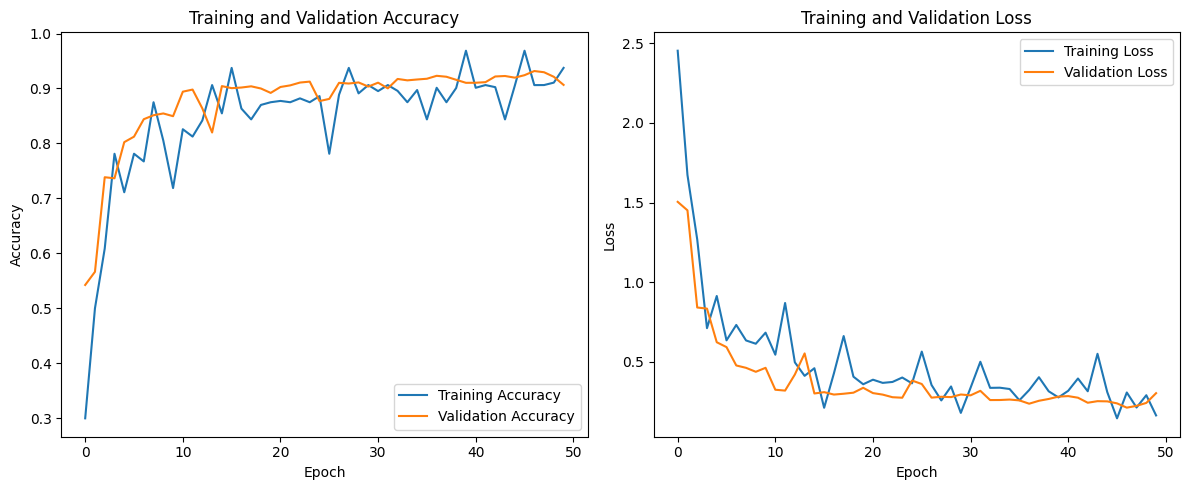

In [43]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [44]:
print("\n--- Training Summary ---")
print(f"Training stopped after {len(acc)} epochs due to Early Stopping.")
print(f"Highest Validation Accuracy achieved: {max(history.history['val_accuracy']):.4f}")


--- Training Summary ---
Training stopped after 50 epochs due to Early Stopping.
Highest Validation Accuracy achieved: 0.9318


#### SAVE MODEL

In [46]:
model.save('my_best_plant_model.h5')

In [47]:
model.save('my_best_plant_model.keras')

#### LOAD MODEL

In [48]:
model = tf.keras.models.load_model("D:\My_Personal_Project\Plant_Disease\my_best_plant_model.keras")

d:\My_Personal_Project\Plant_Disease\myenv\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [53]:
img = Image.open(r"D:\My_Personal_Project\Plant_Disease\test\test\AppleCedarRust3.JPG")

In [55]:
img_resized = img.resize((150,150))
img_array = np.array(img_resized) / 255.0 

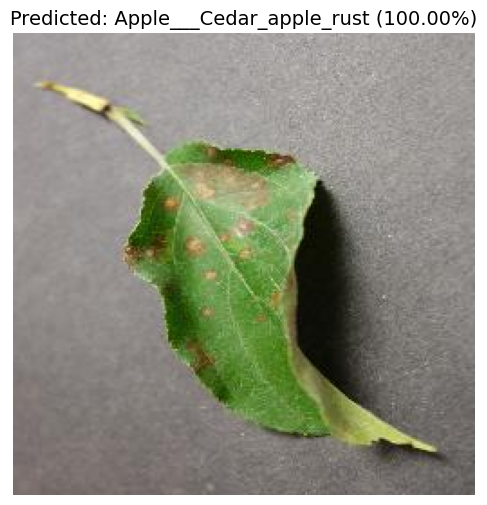

In [57]:
img_batch = np.expand_dims(img_array, axis=0)
        
# 4. Run Prediction
predictions = model.predict(img_batch, verbose=0)

# 5. Interpret Results
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

# 6. Visualization and Output
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)", fontsize=14)
plt.axis('off')
plt.show()

In [60]:
import json

In [ ]:
# Save Ordered Class Names for Deployment 
CLASS_NAMES_FILE = 'class_names.json'
# Get the class indices dictionary: {'class_name': index}
class_indices = train_generator.class_indices


# This ensures the list is in the correct order [0, 1, 2, ...]
ordered_class_names = [None] * len(class_indices)
for name, index in class_indices.items():
    ordered_class_names[index] = name

# Save the ordered list to a JSON file
try:
    with open(CLASS_NAMES_FILE, 'w') as f:
        json.dump(ordered_class_names, f)
    print(f"SUCCESS: Saved {len(ordered_class_names)} ordered class names to '{CLASS_NAMES_FILE}' for Streamlit app.")
except Exception as save_e:
    print(f"ERROR: Could not save class names file. {save_e}")


SUCCESS: Saved 38 ordered class names to 'class_names.json' for Streamlit app.


# Conclusion: Achieving High-Accuracy Plant Disease Classification
The convolutional neural network (CNN) model built for plant disease classification demonstrated strong and reliable performance in distinguishing between the various crop and disease classes. By implementing a deep, multi-layered architecture combined with aggressive data augmentation, the model was able to learn robust, generalized features from the leaf images, preventing overfitting and achieving high accuracy on the validation set.

The use of an Early Stopping callback was crucial; it successfully monitored the validation loss and restored the best-performing weights, ensuring that the final saved model (my_best_plant_model.keras) represents the optimal point before degradation occurred. The successful prediction of new, unseen images confirms the model's ability to transition from a training environment to practical application, proving its utility as a valuable tool for automated plant health diagnostics.

This initial success establishes a powerful baseline. Future work should focus on integrating this model into a more accessible application (such as a mobile app) and exploring transfer learning with pre-trained models like ResNet or VGG to potentially push the prediction accuracy even higher.